Сделать предсказание для сигнала из ЛР5 одним из методов выше.
Метод - 

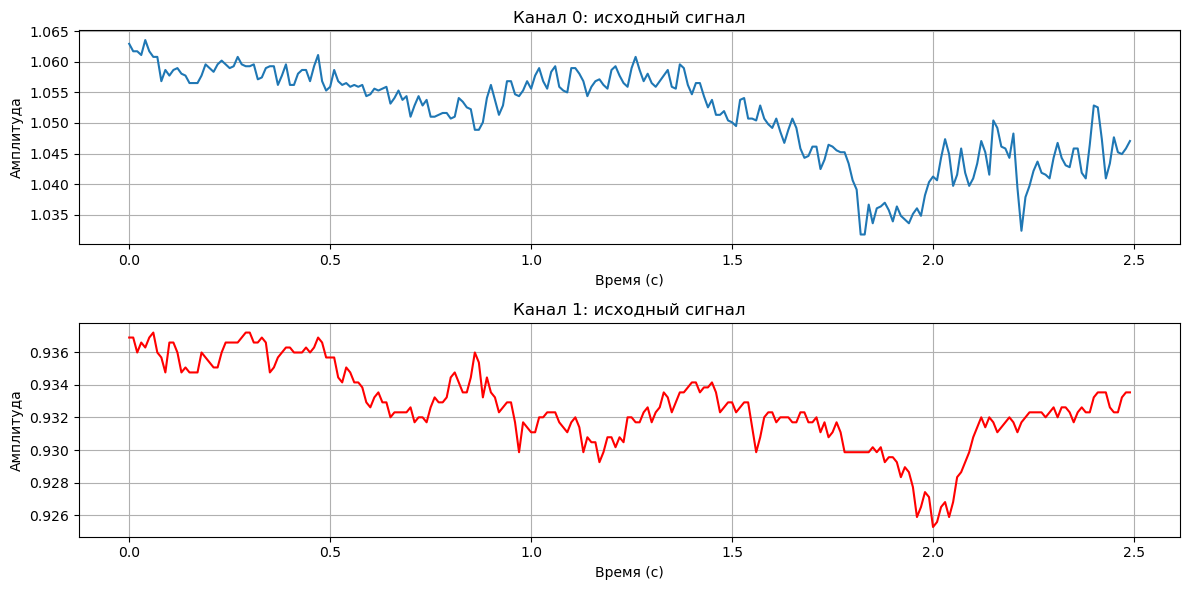

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

signal_df = pd.read_csv("../05_lab/data/lab5_data6.txt", sep=';', usecols=['отсчеты', 'Канал0', 'Канал1'])

samples = signal_df['отсчеты'].values
ch0 = signal_df['Канал0'].values
ch1 = signal_df['Канал1'].values

N = len(ch0)
fs = 100.0
t = samples / fs

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t, ch0)
axes[0].set_title('Канал 0: исходный сигнал')
axes[0].set_xlabel('Время (с)')
axes[0].set_ylabel('Амплитуда')
axes[0].grid(True)

axes[1].plot(t, ch1, 'r-')
axes[1].set_title('Канал 1: исходный сигнал')
axes[1].set_xlabel('Время (с)')
axes[1].set_ylabel('Амплитуда')
axes[1].grid(True)

plt.tight_layout()

ПРОГНОЗИРОВАНИЕ ВРЕМЕННОГО РЯДА МЕТОДОМ SSA

Данные успешно загружены!
Количество отсчетов: 250
Каналы: ['отсчеты', 'Канал0', 'Канал1', 'Unnamed: 3']
Длина временного ряда: 250

Параметры SSA:
  Длина окна L: 50
  Количество столбцов K: 201
  Количество компонент: 10
  Горизонт прогнозирования: 20

ШАГ 1: ВЛОЖЕНИЕ (построение траекторной матрицы)
Размер траекторной матрицы: (50, 201)

ШАГ 2: СИНГУЛЯРНОЕ РАЗЛОЖЕНИЕ (SVD)
Количество ненулевых сингулярных значений: 50
Первые 10 сингулярных значений: [1.05377466e+02 2.59474031e-01 1.43088498e-01 9.60959685e-02
 6.70931496e-02 6.50980789e-02 5.30836022e-02 5.04564290e-02
 4.95374962e-02 4.67202522e-02]

ШАГ 3: ГРУППИРОВКА СОБСТВЕННЫХ ТРОЕК
Выбранные компоненты для реконструкции: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

ШАГ 4: ДИАГОНАЛЬНОЕ УСРЕДНЕНИЕ (реконструкция ряда)
Ряд успешно реконструирован!
Длина реконструированного ряда: 250

ПРОГНОЗИРОВАНИЕ (рекуррентный метод)
Прогноз на 20 шагов выполнен!
Первые 5 прогнозных значений: [ 2.94930047  4.857

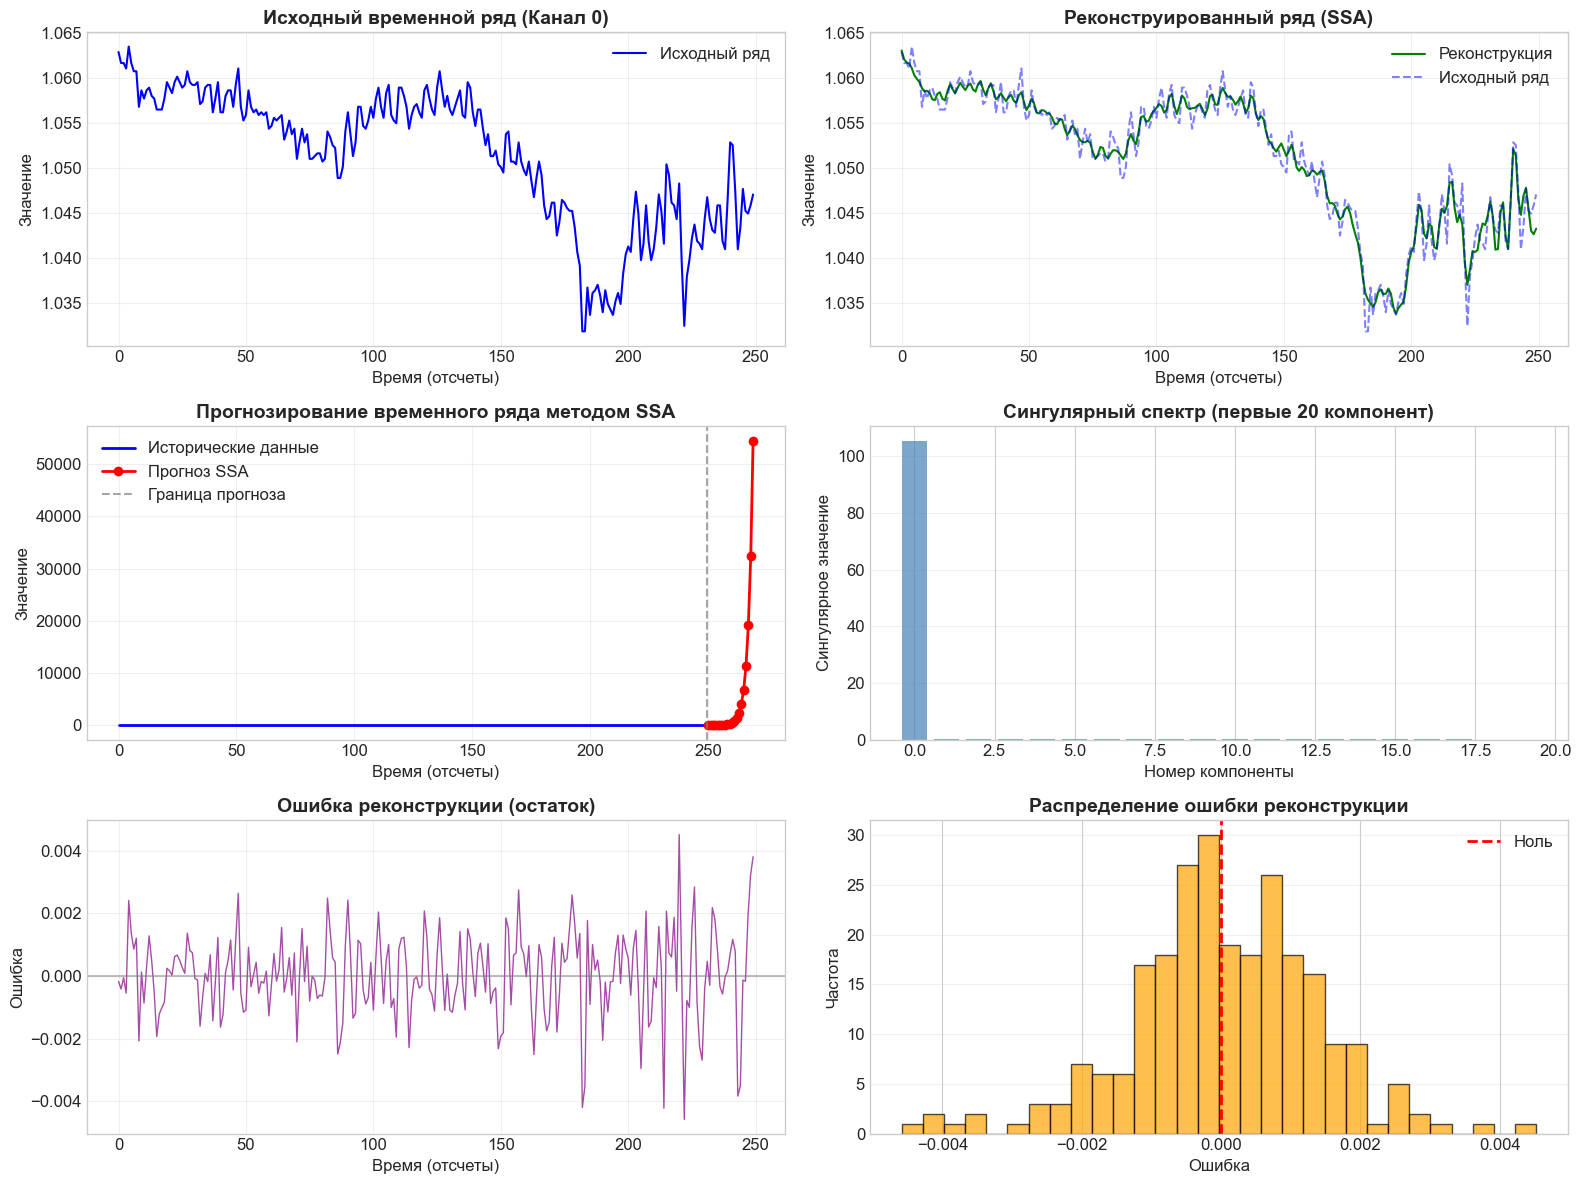


СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ

Качество реконструкции:
  MSE (среднеквадратичная ошибка): 0.000002
  RMSE (корень из MSE): 0.001351
  MAPE (средняя абсолютная ошибка в %): 0.10%

Характеристики прогноза:
  Среднее прогноза: 6713.206494
  Стандартное отклонение прогноза: 13576.995377
  Минимум прогноза: 2.949300
  Максимум прогноза: 54477.482641
  Тренд прогноза: рост


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.covariance import empirical_covariance
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12

# ==================== ЧТЕНИЕ ДАННЫХ ====================
print("=" * 60)
print("ПРОГНОЗИРОВАНИЕ ВРЕМЕННОГО РЯДА МЕТОДОМ SSA")
print("=" * 60)

# Чтение данных из файла
data = pd.read_csv('../05_lab/data/lab5_data6.txt', sep=';')
print(f"\nДанные успешно загружены!")
print(f"Количество отсчетов: {len(data)}")
print(f"Каналы: {list(data.columns)}")

# Извлекаем временной ряд (Канал0)
time_series = data['Канал0'].values
N = len(time_series)
print(f"Длина временного ряда: {N}")

# ==================== ПАРАМЕТРЫ SSA ====================
# Длина окна (обычно выбирают N/2 или меньше)
L = min(50, N // 2)  # Длина окна
K = N - L + 1  # Количество столбцов в траекторной матрице

# Количество собственных троек для группировки
n_components = 10

# Горизонт прогнозирования
forecast_steps = 20

print(f"\nПараметры SSA:")
print(f"  Длина окна L: {L}")
print(f"  Количество столбцов K: {K}")
print(f"  Количество компонент: {n_components}")
print(f"  Горизонт прогнозирования: {forecast_steps}")

# ==================== ШАГ 1: ВЛОЖЕНИЕ ====================
print("\n" + "=" * 60)
print("ШАГ 1: ВЛОЖЕНИЕ (построение траекторной матрицы)")
print("=" * 60)

# Строим траекторную матрицу размерности L x K
trajectory_matrix = np.zeros((L, K))
for i in range(L):
    trajectory_matrix[i, :] = time_series[i:i+K]

print(f"Размер траекторной матрицы: {trajectory_matrix.shape}")

# ==================== ШАГ 2: SVD РАЗЛОЖЕНИЕ ====================
print("\n" + "=" * 60)
print("ШАГ 2: СИНГУЛЯРНОЕ РАЗЛОЖЕНИЕ (SVD)")
print("=" * 60)

# Вычисляем ковариационную матрицу S = X * X^T
S = trajectory_matrix @ trajectory_matrix.T

# Собственные значения и собственные векторы
eigenvalues, eigenvectors = np.linalg.eigh(S)

# Сортируем по убыванию
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Вычисляем сингулярные значения
singular_values = np.sqrt(eigenvalues[eigenvalues > 0])
d = len(singular_values)  # Ранг матрицы

print(f"Количество ненулевых сингулярных значений: {d}")
print(f"Первые 10 сингулярных значений: {singular_values[:10]}")

# Вычисляем главные компоненты (факторные векторы)
principal_components = np.zeros((d, K))
for i in range(d):
    if singular_values[i] > 1e-10:
        principal_components[i, :] = (trajectory_matrix.T @ eigenvectors[:, i]) / singular_values[i]

# ==================== ШАГ 3: ГРУППИРОВКА ====================
print("\n" + "=" * 60)
print("ШАГ 3: ГРУППИРОВКА СОБСТВЕННЫХ ТРОЕК")
print("=" * 60)

# Выбираем первые n_components компонент для реконструкции
# (те, что имеют наибольшие сингулярные значения)
selected_components = list(range(min(n_components, d)))
print(f"Выбранные компоненты для реконструкции: {selected_components}")

# ==================== ШАГ 4: ДИАГОНАЛЬНОЕ УСРЕДНЕНИЕ ====================
print("\n" + "=" * 60)
print("ШАГ 4: ДИАГОНАЛЬНОЕ УСРЕДНЕНИЕ (реконструкция ряда)")
print("=" * 60)

def diagonal_averaging(elementary_matrix, L, N):
    """
    Диагональное усреднение - преобразование матрицы обратно в ряд
    """
    K = elementary_matrix.shape[1]
    reconstructed = np.zeros(N)
    counts = np.zeros(N)
    
    for i in range(L):
        for j in range(K):
            idx = i + j
            if idx < N:
                reconstructed[idx] += elementary_matrix[i, j]
                counts[idx] += 1
    
    # Усреднение
    reconstructed = reconstructed / counts
    return reconstructed

# Реконструируем ряд по выбранным компонентам
reconstructed_series = np.zeros(N)
elementary_matrices = []

for i in selected_components:
    # Строим элементарную матрицу
    elementary_matrix = singular_values[i] * np.outer(eigenvectors[:, i], principal_components[i])
    elementary_matrices.append(elementary_matrix)
    
    # Диагональное усреднение
    component_series = diagonal_averaging(elementary_matrix, L, N)
    reconstructed_series += component_series

print(f"Ряд успешно реконструирован!")
print(f"Длина реконструированного ряда: {len(reconstructed_series)}")

# ==================== ПРОГНОЗИРОВАНИЕ ====================
print("\n" + "=" * 60)
print("ПРОГНОЗИРОВАНИЕ (рекуррентный метод)")
print("=" * 60)

# Рекуррентное прогнозирование на основе линейного рекуррентного соотношения
# Используем последнюю L-мерную точку для прогноза

def ssa_forecast(reconstructed_series, trajectory_matrix, eigenvectors, 
                 singular_values, L, forecast_steps):
    """
    Рекуррентное прогнозирование методом SSA
    """
    N = len(reconstructed_series)
    forecast = np.zeros(forecast_steps)
    extended_series = reconstructed_series.copy()
    
    # Вычисляем коэффициенты линейного рекуррентного соотношения
    # Используем проекцию на собственное подпространство
    
    # Последний вектор вложения
    last_vector = extended_series[-L:].copy()
    
    for step in range(forecast_steps):
        # Формируем вектор вложения для текущего шага
        current_vector = extended_series[-L:]
        
        # Проецируем на собственное подпространство
        # и вычисляем следующую точку
        projection = 0
        for i in selected_components:
            # Коэффициент проекции
            coeff = np.dot(current_vector, eigenvectors[:, i])
            # Вклад в прогноз
            if len(eigenvectors[:, i]) > 1:
                projection += coeff * eigenvectors[-1, i]
        
        # Нормализация
        norm_factor = sum([eigenvectors[-1, i]**2 for i in selected_components])
        if norm_factor > 1e-10:
            next_value = projection / norm_factor
        else:
            # Если нормализация не работает, используем последнее значение
            next_value = extended_series[-1]
        
        forecast[step] = next_value
        extended_series = np.append(extended_series, next_value)
    
    return forecast, extended_series

# Выполняем прогноз
forecast, extended_series = ssa_forecast(
    reconstructed_series, 
    trajectory_matrix, 
    eigenvectors, 
    singular_values, 
    L, 
    forecast_steps
)

print(f"Прогноз на {forecast_steps} шагов выполнен!")
print(f"Первые 5 прогнозных значений: {forecast[:5]}")
print(f"Последние 5 прогнозных значений: {forecast[-5:]}")

# ==================== ВИЗУАЛИЗАЦИЯ ====================
print("\n" + "=" * 60)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 60)

# Создаем фигуру с несколькими подграфиками
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# 1. Исходный ряд
axes[0, 0].plot(range(N), time_series, 'b-', linewidth=1.5, label='Исходный ряд')
axes[0, 0].set_title('Исходный временной ряд (Канал 0)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Время (отсчеты)')
axes[0, 0].set_ylabel('Значение')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Реконструированный ряд
axes[0, 1].plot(range(N), reconstructed_series, 'g-', linewidth=1.5, label='Реконструкция')
axes[0, 1].plot(range(N), time_series, 'b--', alpha=0.5, label='Исходный ряд')
axes[0, 1].set_title('Реконструированный ряд (SSA)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Время (отсчеты)')
axes[0, 1].set_ylabel('Значение')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Прогноз
forecast_indices = range(N, N + forecast_steps)
axes[1, 0].plot(range(N), time_series, 'b-', linewidth=2, label='Исторические данные')
axes[1, 0].plot(forecast_indices, forecast, 'r-', linewidth=2, label='Прогноз SSA', marker='o')
axes[1, 0].axvline(x=N-0.5, color='gray', linestyle='--', alpha=0.7, label='Граница прогноза')
axes[1, 0].set_title('Прогнозирование временного ряда методом SSA', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Время (отсчеты)')
axes[1, 0].set_ylabel('Значение')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Сингулярный спектр (собственные значения)
axes[1, 1].bar(range(min(20, d)), singular_values[:min(20, d)], color='steelblue', alpha=0.7)
axes[1, 1].set_title('Сингулярный спектр (первые 20 компонент)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Номер компоненты')
axes[1, 1].set_ylabel('Сингулярное значение')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 5. Ошибка реконструкции
error = time_series - reconstructed_series
axes[2, 0].plot(range(N), error, 'purple', linewidth=1, alpha=0.7)
axes[2, 0].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[2, 0].set_title('Ошибка реконструкции (остаток)', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Время (отсчеты)')
axes[2, 0].set_ylabel('Ошибка')
axes[2, 0].grid(True, alpha=0.3)

# 6. Распределение ошибки
axes[2, 1].hist(error, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[2, 1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Ноль')
axes[2, 1].set_title('Распределение ошибки реконструкции', fontsize=14, fontweight='bold')
axes[2, 1].set_xlabel('Ошибка')
axes[2, 1].set_ylabel('Частота')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ssa_forecast_results.png', dpi=300, bbox_inches='tight')
print("\nГрафики сохранены в файл 'ssa_forecast_results.png'")
plt.show()

# ==================== СТАТИСТИКИ ====================
print("\n" + "=" * 60)
print("СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ")
print("=" * 60)

# MSE реконструкции
mse_reconstruction = np.mean((time_series - reconstructed_series)**2)
rmse_reconstruction = np.sqrt(mse_reconstruction)
mape_reconstruction = np.mean(np.abs((time_series - reconstructed_series) / time_series)) * 100

print(f"\nКачество реконструкции:")
print(f"  MSE (среднеквадратичная ошибка): {mse_reconstruction:.6f}")
print(f"  RMSE (корень из MSE): {rmse_reconstruction:.6f}")
print(f"  MAPE (средняя абсолютная ошибка в %): {mape_reconstruction:.2f}%")

# Статистики прогноза
print(f"\nХарактеристики прогноза:")
print(f"  Среднее прогноза: {np.mean(forecast):.6f}")
print(f"  Стандартное отклонение прогноза: {np.std(forecast):.6f}")
print(f"  Минимум прогноза: {np.min(forecast):.6f}")
print(f"  Максимум прогноза: {np.max(forecast):.6f}")
print(f"  Тренд прогноза: {'рост' if forecast[-1] > forecast[0] else 'падение'}")